# Day 3b - Link Prediction

Link prediction asks: given two nodes, should there be an edge between them? In this practical, each row in a dataframe is one possible pair of nodes. We build features for those pairs, train simple models, and compare how well they find hidden edges.

## Learning objectives
By the end of this notebook you will be able to:
1. Explain link prediction as binary classification on node pairs.
2. Compute local similarity heuristics (Jaccard, Adamic-Adar, ...).
3. Build path-based scores, Katz scores, and node embeddings (SVD, node2vec).
4. Train a small GraphSAGE model with PyTorch Geometric. [optional]
5. Compare predictors using AUC and inspect which pairs each method ranks highly.

## How to work
For every method: run the baseline as written, note the AUC, try the change listed under **Change this**, rerun, and compare.

## Notebook map
- **Introduction**: data, prediction target, candidate-pair dataframe, and evaluation helper
- **Part 1**: Local similarity heuristics
- **Part 2**: Paths and Katz
- **Part 3**: Node embeddings (SVD, node2vec)
- **Part 4**: Graph Neural Network (GraphSAGE)
- **Part 5**: Compare methods and top predictions
- **Appendix**: how the test sets were created


In [ ]:
# On Colab, run this cell first in a fresh runtime, before importing numpy/pandas.
# We use NetworKit for node2vec (the external PyPI `node2vec` package has
# dependency problems on Colab) and PyTorch Geometric for GraphSAGE.

!pip install -q python-igraph networkit scikit-learn pandas matplotlib seaborn

import os, torch
os.environ['TORCH'] = torch.__version__
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-geometric
!git clone https://github.com/jgarciab/NetworkScience.git


In [1]:
# # Path to the data folder
# # On your computer:
# path_data = "../../Data/"
# # On Colab uncomment:
path_data = "/content/NetworkScience/Data/"


In [2]:
# Core network libraries
import igraph as ig
import networkit as nk

# Data and numerics
import numpy as np
import pandas as pd
import random

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# ML helpers
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import SpectralEmbedding
from scipy.spatial.distance import cdist

# GNN libraries used in Part 4
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

pd.options.mode.chained_assignment = None

# Visual style for the whole notebook
custom_params = {
    "axes.spines.right": False, "axes.spines.top": False, "axes.spines.left": False, "axes.spines.bottom": False,
    "lines.linewidth": 2, "grid.color": "lightgray", "legend.frameon": False,
    "xtick.labelcolor": "#484848", "ytick.labelcolor": "#484848",
    "xtick.color": "#484848", "ytick.color": "#484848",
    "text.color": "#484848", "axes.labelcolor": "#484848",
    "axes.titlecolor": "#484848", "figure.figsize": [5, 3],
    "axes.titlelocation": "left",
    "xaxis.labellocation": "left",
    "yaxis.labellocation": "bottom",
}
palette = ["#3d348b", "#e6af2e", "#191716", "#e0e2db"]
sns.set_theme(context='paper', style='white', palette=palette, font_scale=1.3, color_codes=True, rc=custom_params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

# Reproducibility seeds
np.random.seed(1546)
torch.manual_seed(1546)
random.seed(1546)


/Users/garci061/miniforge3/envs/networks/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Introduction: data and prediction target

We use a **Twitter mention network** and a **yeast protein-protein interaction (PPI) network**. We will use the Twitter network first.

Each of the datasets have two files:
- `<dataset>_network_prediction.graphml`: the training graph. Some real edges were held-out (i.e. removed) to understand how well our methods perform.
- `<dataset>_network_prediction_test.csv`: the held-out node pairs. `label = 1` means a held-out real edge that we removed from the graph; `label = 0` means a node pair that is not connected.

The practical question is: can we use the training graph to guess which held-out node pairs are real edges?

The prediction target is a row in a dataframe: two nodes, plus a label saying whether that pair is one of the held-out real edges. We will hide the labels while making predictions, then reveal them when we evaluate the models.


### Choose a dataset and load the graph

Use `ig.Graph.Read_GraphML` and print basic statistics: number of nodes/edges, density, global clustering (`transitivity_undirected`), and degree assortativity.


In [3]:
# choose one dataset and load its training graph.
# Small change to try later: change `dataset` from "twitter" to "ppi".
dataset = "twitter"  # options: "twitter", "ppi"

g = ig.Graph.Read_GraphML(f"{path_data}/{dataset}_network_prediction.graphml")
g.simplify()

print(f"Loaded the '{dataset}' graph")
print(f"  nodes (n)     : {g.vcount():,}")
print(f"  edges (m)     : {g.ecount():,}")
print(f"  density       : {g.density():.5f}")
print(f"  transitivity  : {g.transitivity_undirected():.3f}")
print(f"  assortativity : {g.assortativity_degree():.3f}")
print(f"  vertex attrs  : {g.vs.attributes()}")


Loaded the 'twitter' graph
  nodes (n)     : 1,554
  edges (m)     : 24,631
  density       : 0.02041
  transitivity  : 0.172
  assortativity : -0.033
  vertex attrs  : ['label', 'id']


### Load the held-out test set

The test CSV is tab-separated. The two node columns use the same numeric IDs as the GraphML file. We also attach readable node labels (the actual Twitter accounts or protein labels), which makes the examples easier to inspect.


In [4]:
# load the labelled held-out node pairs.
df_test = pd.read_csv(
    f"{path_data}/{dataset}_network_prediction_test.csv",
    sep="\t",
    index_col=0,
)
df_test.columns = ["node_u", "node_v", "label"]
df_test[["node_u", "node_v"]] = df_test[["node_u", "node_v"]].astype(str)
df_test = df_test.drop_duplicates(subset=["node_u", "node_v"])

# Add the label names to the dataset
id_to_label = dict(zip(g.vs["id"], g.vs["label"]))
df_test["source"] = df_test["node_u"].map(id_to_label)
df_test["target"] = df_test["node_v"].map(id_to_label)

print("Hidden test set:", df_test.shape)
print("  positives:", int((df_test["label"] == 1).sum()))
print("  negatives:", int((df_test["label"] == 0).sum()))
df_test.head()


Hidden test set: (12152, 5)
  positives: 6082
  negatives: 6070


,node_u,node_v,label,source,target
0,448,37,1,necsi,bansallab
1,165,881,1,LHDnets,uvmcems
2,118,102,1,estebanmoro,clauwa
3,574,236,1,TravisEGibson,_jgyou
4,364,937,1,elisa_omodei,ponguru


### Whiteboard challenge: predict 10 held-out pairs

Below are 10 held-out pairs. Look only at the node names and write down which pairs you think are real missing edges.

Later, after each method has made predictions, call `show_whiteboard_predictions("method_name")` to see that method's scores for these same 10 pairs. The labels stay hidden until we explicitly ask to show them.


In [7]:
whiteboard_pairs = df_test.sample(10, random_state=1546).copy()
whiteboard_pairs["whiteboard_id"] = np.arange(1, len(whiteboard_pairs) + 1)
display(whiteboard_pairs[["whiteboard_id", "source", "target"]].reset_index(drop=True))


,whiteboard_id,source,target
0,1,PolarBearby,DrBreaky
1,2,robysinatra,m_rosvall
2,3,GiulioRossetti,WeiyuZ
3,4,official_SYNS,joshua_a_becker
4,5,yy,DanLarremore
5,6,katjaQheuer,VeraPancaldi
6,7,citron_daniel,richardclegg
7,8,katjaQheuer,svscarpino
8,9,ricgallotti,sees_lab
9,10,phdskat,wtgrantfdn


### Quick visual check

Plot the training graph once. This is just to see the overall shape of the network.


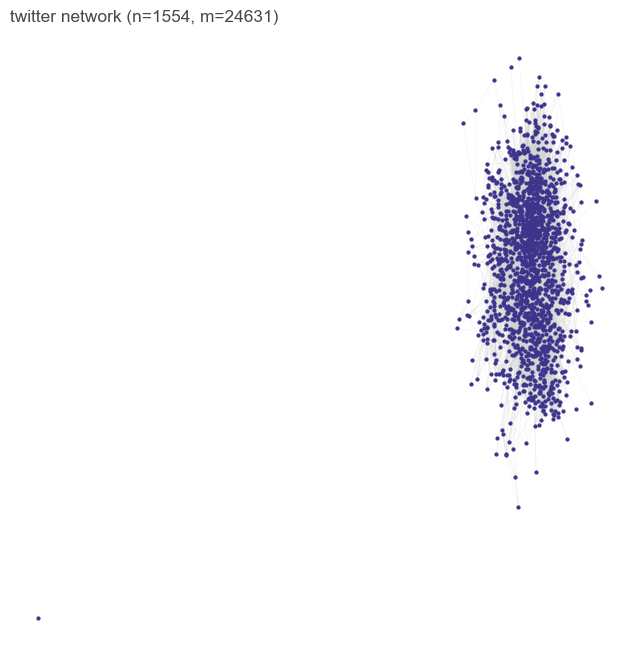

In [9]:
# quick shape check, not a final publication plot.
# Small change to try: lower `niter` to 50 for speed, or raise it to 500.
niter = 200
layout = g.layout_fruchterman_reingold(niter=niter)
coords = np.array(layout.coords)

fig, ax = plt.subplots(figsize=(8, 8))
for e in g.es:
    x0, y0 = coords[e.source]
    x1, y1 = coords[e.target]
    ax.plot([x0, x1], [y0, y1], color="lightgray", alpha=0.3, linewidth=0.4, zorder=1)
ax.scatter(coords[:, 0], coords[:, 1], s=5, color=palette[0], zorder=2)
ax.set_axis_off()
ax.set_title(f"{dataset} network (n={g.vcount()}, m={g.ecount()})")
plt.show()


---
## Introduction: candidate-pair dataframe

Machine-learning tools expect a table: rows are examples, columns are features, and one column is the label. For link prediction, each row is one candidate pair `(u, v)`. The column `edge` is the training label: `1` if the pair is an observed edge in the training graph, `0` if not. The graph gives us the positives; every other node pair is a negative.

We keep two kinds of node identifiers: `node_u`/`node_v` are the node IDs (useful for reading tables), and `u_idx`/`v_idx` are the row numbers of the nodes inside the graph (useful for indexing matrices such as `A[u_idx, v_idx]`).


### Build `df_pairs`

`df_pairs` contains all candidate links we will train on: every ordered pair of distinct nodes. We also mark which pairs appear in the held-out test set (`in_test`), so Part 4 can avoid them when sampling training negatives.


In [10]:
# One row per ordered pair of distinct nodes; `edge=1` marks observed training edges.
A = np.array(g.get_adjacency().data, dtype=float)
np.fill_diagonal(A, 0)

node_ids = np.array([str(node_id) for node_id in g.vs["id"]])
n = g.vcount()

pair_u, pair_v = np.where(~np.eye(n, dtype=bool))  # all ordered pairs, no self-pairs
df_pairs = pd.DataFrame({
    "node_u": node_ids[pair_u],
    "node_v": node_ids[pair_v],
    "u_idx": pair_u,
    "v_idx": pair_v,
    "edge": A[pair_u, pair_v].astype(int),
})

# Mark pairs that appear in the held-out test set, in either direction.
test_keys = set(zip(df_test["node_u"], df_test["node_v"]))
test_keys |= {(v, u) for u, v in test_keys}
df_pairs["in_test"] = [(u, v) in test_keys for u, v in zip(df_pairs["node_u"], df_pairs["node_v"])]

print("df_pairs:", df_pairs.shape)
print("positive training pairs:", int(df_pairs["edge"].sum()))
print("negative training pairs:", int((df_pairs["edge"] == 0).sum()))
df_pairs.head()


df_pairs: (2413362, 6)
positive training pairs: 49262
negative training pairs: 2364100


,node_u,node_v,u_idx,v_idx,edge,in_test
0,0,1,0,1,1,False
1,0,217,0,2,1,False
2,0,476,0,3,1,False
3,0,1324,0,4,1,False
4,0,103,0,5,1,False


---
## Introduction: evaluation helper

For each method we add a feature column to `df_pairs`, train a logistic regression on the training pairs, and evaluate it on the held-out `df_test` pairs.

AUC is a ranking score. An AUC of `0.5` is random guessing; an AUC of `1.0` is perfect ranking. You can read it as: if we pick one true hidden edge and one non-edge, how often does the model give the true edge the higher score?

The helper also saves predictions for the 10 whiteboard pairs. After running any named method, use `show_whiteboard_predictions("method_name")`. Set `show_labels=True` only when we are ready to reveal the answers.


In [46]:
# Containers filled as we go.
auc_log = {}
test_prediction_log = {}


def create_predictions(columns, name):
    """Train a logistic regression on df_pairs[columns], evaluate on df_test.

    Prints the coefficients and the held-out AUC, plots the ROC curve, and
    saves the results in test_prediction_log[name] and auc_log[name].
    """
    if isinstance(columns, str):
        columns = [columns]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced"),
    )
    df_train = df_pairs.loc[~df_pairs["in_test"]]
    model.fit(df_train[columns], df_train["edge"])

    print("Model coefficients")
    for col, coef in zip(columns, model[-1].coef_[0]):
        print(f"  {col}: {coef: .2f}")

    # Attach the same feature columns to the held-out pairs.
    test = df_test.merge(df_pairs, on=["node_u", "node_v"], how="inner", validate="1:1")
    y_score = model.predict_proba(test[columns])[:, 1]
    auc = roc_auc_score(test["label"], y_score)

    df_out = test[["node_u", "node_v", "source", "target", "label"]].copy()
    df_out["pred_prob"] = y_score
    df_out["pred"] = (y_score >= 0.5).astype(int)
    test_prediction_log[name] = df_out
    auc_log[name] = auc

    RocCurveDisplay.from_predictions(test["label"], y_score)
    plt.plot([0, 1], [0, 1], "--", color="lightgray")
    plt.grid(True)
    plt.title(f"ROC - {name}")
    plt.show()

    print("-" * 50)
    print(f"AUC on the held-out test set: {auc:.3f}")
    print("-" * 50)


def show_whiteboard_predictions(name, show_labels=False):
    """Show one method's predictions for the 10 whiteboard pairs."""
    if name not in test_prediction_log:
        raise KeyError(f"No predictions for {name!r}. Run it first, or pick one of: {sorted(test_prediction_log)}")

    out = whiteboard_pairs[["whiteboard_id", "node_u", "node_v", "source", "target", "label"]].merge(
        test_prediction_log[name][["node_u", "node_v", "pred_prob"]],
        on=["node_u", "node_v"],
    )
    out["probability"] = out["pred_prob"].round(3)
    out["prediction"] = np.where(out["pred_prob"] >= 0.5, "edge", "no edge")

    show_cols = ["whiteboard_id", "source", "target", "probability", "prediction"]
    if show_labels:
        out["true_label"] = np.where(out["label"] == 1, "edge", "no edge")
        show_cols.append("true_label")

    return out.sort_values("probability", ascending=False)[show_cols].reset_index(drop=True)


---
## Part 1: Local similarity heuristics

Local heuristics look only near the two candidate nodes. The intuition is simple: if two nodes share neighbours, they may be more likely to connect.

Let $\Gamma(u)$ be the neighbours of node $u$, and $k_u$ the number of neighbors $k_u = |\Gamma(u)|$. Every heuristic below can be computed from two ingredients, prepared in the next cell:

- `CN[u, v]` = number of common neighbours $|\Gamma(u) \cap \Gamma(v)|$ (this is just `(A @ A)[u, v]`);
- `k[u]` = degree of node $u$.

| Heuristic | Formula | Code |
|---|---|---|
| Jaccard | $\frac{\vert\Gamma(u) \cap \Gamma(v)\vert}{\vert\Gamma(u) \cup \Gamma(v)\vert}$ | `g.similarity_jaccard(pairs=...)` |
| Dice | $\frac{2\vert\Gamma(u) \cap \Gamma(v)\vert}{k_u + k_v}$ | `g.similarity_dice(pairs=...)` |
| Adamic-Adar | $\sum_{w \in \Gamma(u) \cap \Gamma(v)} \frac{1}{\log k_w}$ | `np.array(g.similarity_inverse_log_weighted())[pair_u, pair_v]` |
| Salton (cosine) | $\frac{\vert\Gamma(u) \cap \Gamma(v)\vert}{\sqrt{k_u k_v}}$ | `CN[pair_u, pair_v] / np.sqrt(k[pair_u] * k[pair_v])` |
| Hub-promoted | $\frac{\vert\Gamma(u) \cap \Gamma(v)\vert}{\min(k_u, k_v)}$ | `CN[pair_u, pair_v] / np.minimum(k[pair_u], k[pair_v])` |
| Hub-suppressed | $\frac{\vert\Gamma(u) \cap \Gamma(v)\vert}{\max(k_u, k_v)}$ | `CN[pair_u, pair_v] / np.maximum(k[pair_u], k[pair_v])` |
| Leicht-Holme-Newman | $\frac{\vert\Gamma(u) \cap \Gamma(v)\vert}{k_u k_v}$ | `CN[pair_u, pair_v] / (k[pair_u] * k[pair_v])` |
| Resource Allocation | $\sum_{w \in \Gamma(u) \cap \Gamma(v)} \frac{1}{k_w}$ | `(A @ np.diag(1 / np.maximum(k, 1)) @ A)[pair_u, pair_v]` |
| Preferential Attachment | $k_u k_v$ | `k[pair_u] * k[pair_v]` |

Some formulas divide by the degree, which is zero for isolated nodes. Clean the result with `np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)`, as the Jaccard cell shows.

We write the Jaccard example once. Your turn: pick another heuristic, save it under its own column name, and compare the AUC.


In [47]:
# Ingredients for the heuristic formulas.
CN = A @ A                # CN[u, v] = number of common neighbours of u and v
np.fill_diagonal(CN, 0)   # Don't count paths to yourself
k = A.sum(axis=1)         # k[u] = degree of node u

print("adjacency matrix A:", A.shape)
print("example: nodes 0 and 1 share", int(CN[0, 1]), "neighbours")


adjacency matrix A: (1554, 1554)
example: nodes 0 and 1 share 3 neighbours


### One worked example: Jaccard

Jaccard asks: what fraction of the two neighbourhoods is shared?

$J(u,v)=\frac{|\Gamma(u) \cap \Gamma(v)|}{|\Gamma(u) \cup \Gamma(v)|}$

**Change this:** compute another heuristic from the table above, save it under its own column name, rerun the cell, and call `show_whiteboard_predictions(score_name)`.


Model coefficients
  jaccard:  1.86


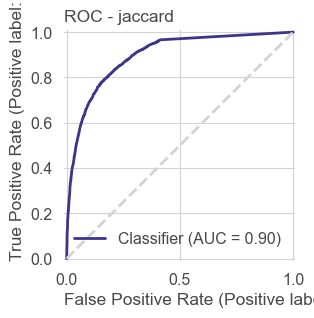

--------------------------------------------------
AUC on the held-out test set: 0.895
--------------------------------------------------


,whiteboard_id,source,target,probability,prediction
0,5,yy,DanLarremore,0.999,edge
1,6,katjaQheuer,VeraPancaldi,0.999,edge
2,9,ricgallotti,sees_lab,0.991,edge
3,2,robysinatra,m_rosvall,0.975,edge
4,4,official_SYNS,joshua_a_becker,0.808,edge
5,7,citron_daniel,richardclegg,0.727,edge
6,8,katjaQheuer,svscarpino,0.339,no edge
7,1,PolarBearby,DrBreaky,0.051,no edge
8,3,GiulioRossetti,WeiyuZ,0.051,no edge
9,10,phdskat,wtgrantfdn,0.051,no edge


In [48]:
score_name = "jaccard"
scores = g.similarity_jaccard(pairs=df_pairs[["u_idx", "v_idx"]].to_numpy())

# For example, with numpy instead:
# score_name = "preferential_attachment"
# scores = k[pair_u] * k[pair_v]

df_pairs[score_name] = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)

create_predictions(score_name, name=score_name)

show_whiteboard_predictions(score_name)


In [18]:
# create_predictions("jaccard") updates test_prediction_log["jaccard"] with the predictions
test_prediction_log["jaccard"]

,node_u,node_v,source,target,label,pred_prob,pred
0,448,37,necsi,bansallab,1,0.397736,0
1,165,881,LHDnets,uvmcems,1,0.512341,1
2,118,102,estebanmoro,clauwa,1,0.997407,1
3,574,236,TravisEGibson,_jgyou,1,0.781832,1
4,364,937,elisa_omodei,ponguru,1,0.988569,1
...,...,...,...,...,...,...,...
12147,328,456,mtizzoni,nerdsitu,0,0.990828,1
12148,1083,459,DrHelenKara,umsi,0,0.053796,0
12149,567,1504,blengyelb,EurekAlert,0,0.119571,0
12150,254,1281,BovetAlexandre,projectcornelia,0,0.173486,0


**What to notice.** Local heuristics can be very strong here because the hidden edges were removed from the same network. Many hidden positives still sit in dense neighbourhoods, so a simple structural score can rank them well.


---
## Part 2: Paths and Katz

Local heuristics only look nearby. Path features ask whether two nodes are connected by short walks through the graph.


### Powers of the adjacency matrix

The entry $(A^k)_{uv}$ counts the number of walks of length $k$ from node $u$ to node $v$.

Short walks usually mean stronger evidence than long walks, but trying a few lengths is useful.

**Change this:** after the baseline run, change `path_columns` from `["a2", "a3", "a4"]` to `["a2"]`, then to `["a3"]`, then to `["a2", "a3"]`. Rerun the cell each time and record which walk lengths help most.


Model coefficients
  a2:  0.16
  a3:  41.16
  a4: -40.17


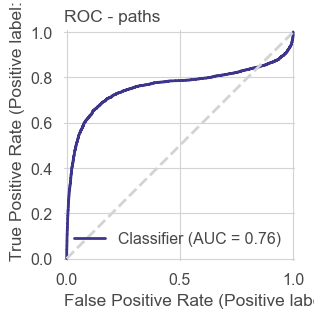

--------------------------------------------------
AUC on the held-out test set: 0.761
--------------------------------------------------


In [20]:
# A^2, A^3 and A^4 count walks of increasing length.
A2 = A @ A
A3 = A2 @ A
A4 = A3 @ A
for M in (A2, A3, A4):
    np.fill_diagonal(M, 0)

df_pairs["a2"] = A2[pair_u, pair_v]
df_pairs["a3"] = A3[pair_u, pair_v]
df_pairs["a4"] = A4[pair_u, pair_v]

# Change this list to compare different walk lengths.
path_columns = ["a2", "a3", "a4"]

create_predictions(path_columns, name="paths")


### Katz similarity

Katz adds up walks of all lengths, but longer walks count less:

$S = \sum_{k=1}^{\infty} \beta^k P^k = (I - \beta P)^{-1} - I$

Here $P=D^{-1}A$ is the row-normalized adjacency matrix. Row-normalization makes the scale easy: any $0 < \beta < 1$ is safe, and values closer to `1` give longer walks more influence.

**Change this:** after the baseline run, change `beta` to `0.50`, then to `0.99`. Rerun the cell each time and record how the AUC changes.


row-normalized Katz with beta = 0.95
Model coefficients
  katz:  1.72


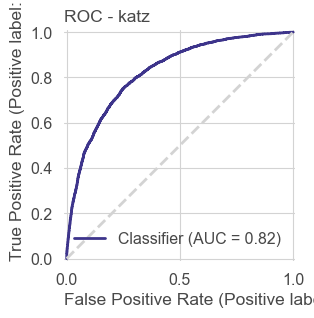

--------------------------------------------------
AUC on the held-out test set: 0.825
--------------------------------------------------


In [24]:
# Katz sums all path lengths, down-weighting longer paths.
def katz_similarity(A, beta=0.95):
    """Closed-form Katz similarity on the row-normalized adjacency matrix."""
    if not 0 < beta < 1:
        raise ValueError("For row-normalized Katz, choose 0 < beta < 1.")

    row_sums = A.sum(axis=1, keepdims=True)
    P = np.divide(A, row_sums, out=np.zeros_like(A, dtype=float), where=row_sums > 0)

    I = np.eye(P.shape[0])
    S = np.linalg.inv(I - beta * P) - I
    print(f"row-normalized Katz with beta = {beta:.2f}")
    return S

beta = 0.95
S_katz = katz_similarity(A, beta=beta)
np.fill_diagonal(S_katz, 0)

df_pairs["katz"] = S_katz[pair_u, pair_v]
create_predictions("katz", name="katz")


---
## Part 3: Node embeddings

Embeddings turn each node into a vector. Then a pair of nodes can be compared by the distance between their vectors.

We try two families: matrix-based embeddings of the adjacency matrix (SVD, with PCA and Laplacian Eigenmaps as alternatives), and node2vec random walks.


### Pairwise vector comparisons

Embeddings give each node a vector. To turn two node vectors into an edge score, we compare the vectors: smaller distance means the nodes are more similar. The classifier then learns whether similar vectors tend to mean `edge = 1`.

We use scipy's `cdist`, which computes all pairwise distances in one call. Useful metrics here: `"cityblock"` (L1), `"sqeuclidean"` (squared L2), and `"cosine"` (1 - cosine similarity). The toy example below shows how each metric behaves: A and B point in almost the same direction, C is orthogonal to both.


In [31]:
toy_vectorA = np.array([[1.0, 0.45]])
toy_vectorB = np.array([[0.5, 0.2]])

for metric in ["cityblock", "sqeuclidean", "cosine"]:
    D = cdist(toy_vectorA, toy_vectorB, metric=metric)
    print(metric, D)

# Note that cosine distance is very small since both vectors point to the same direction

cityblock [[0.75]]
sqeuclidean [[0.3125]]
cosine [[0.00089652]]


### Matrix-based embeddings (SVD, PCA, Laplacian Eigenmaps)

SVD compresses the adjacency matrix into a smaller number of dimensions:

$A \approx U\Sigma V^T$

Nodes with similar connection patterns should get similar vectors. PCA and Laplacian Eigenmaps (LE) are two other classic ways to embed the adjacency matrix; both are imported and ready to try.

**Change this:** after the baseline run, change `n_components` from `10` to `5` or `20`, and change `svd_metric` from `"cityblock"` to `"sqeuclidean"` or `"cosine"`. Then swap the embedding method to PCA or LE by uncommenting the matching line. Rerun the cell and record which combination works best.


Model coefficients
  svd:  0.76


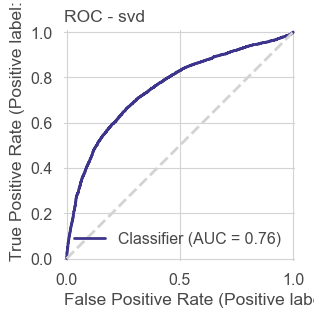

--------------------------------------------------
AUC on the held-out test set: 0.756
--------------------------------------------------


In [32]:
# Matrix-based embeddings compress each node into a short vector.
# Change n_components, svd_metric, or the embedding method, then rerun this cell.
n_components = 10

emb = TruncatedSVD(n_components=n_components, random_state=1546).fit(A).components_.T
# Also try:
# emb = PCA(n_components=n_components, random_state=1546).fit_transform(A)
# emb = SpectralEmbedding(n_components=n_components, affinity="precomputed").fit_transform(A)  # Laplacian Eigenmaps

svd_metric = "cityblock"  # options: "cityblock", "sqeuclidean", "cosine"
dist_svd = cdist(emb, emb, metric=svd_metric)
df_pairs["svd"] = dist_svd[pair_u, pair_v]

create_predictions("svd", name="svd")


### node2vec with NetworKit

node2vec makes short biased random walks on the graph. It then learns node vectors so that nodes appearing in similar walk contexts get similar embeddings.

Step by step:
1. Convert the igraph training graph to a NetworKit graph.
2. Run `nk.embedding.Node2Vec` to sample biased walks and learn embeddings.
3. Put the learned vectors back in igraph node order.
4. Compare node vectors with cosine distance.
5. Train the same link-prediction classifier as before.

Key settings:
- **`dimensions`**: vector size.
- **`walk_length`**: how long each walk is.
- **`num_walks`**: how many walks start from each node.
- **`node2vec_metric`**: how we compare the learned node vectors.
- **`p`**: high values discourage immediately walking back.
- **`q`**: low values explore outward; high values stay more local.

NetworKit Node2Vec does not accept isolated nodes, so the code runs it on the non-isolated part of the graph and gives isolated nodes an all-zero vector.

**Change this:** after the baseline run, try `q = 0.5` for more outward exploration, then `q = 2.0` for more local walks. You can also change `dimensions`, `walk_length`, `num_walks`, or `node2vec_metric`. Rerun the cell and record both the AUC and how the walk behaviour changed.


NetworKit graph: 1553 nodes, 24631 edges
isolated nodes with zero vectors: 1
Turn node vectors into pair features and evaluate
Model coefficients
  node2vec: -1.52


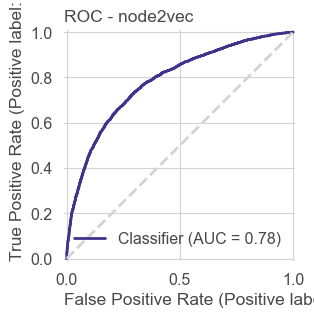

--------------------------------------------------
AUC on the held-out test set: 0.784
--------------------------------------------------


In [33]:
# NetworKit Node2Vec learns node embeddings from biased random walks.
# Change q, dimensions, walk_length, or num_walks and rerun this cell.
dimensions = 64
walk_length = 80
num_walks = 10
p = 1.0
q = 1.0
node2vec_metric = "cosine"  # options: "cityblock", "sqeuclidean", "cosine"

nk.setNumberOfThreads(1)
nk.setSeed(1546, False)

nonisolated = [i for i, d in enumerate(g.degree()) if d > 0]
old_to_nk = {old: i for i, old in enumerate(nonisolated)}

G_nk = nk.Graph(len(nonisolated), weighted=False, directed=False)
for u, v in g.get_edgelist():
    if u in old_to_nk and v in old_to_nk:
        G_nk.addEdge(old_to_nk[u], old_to_nk[v])

print("NetworKit graph:", G_nk.numberOfNodes(), "nodes,", G_nk.numberOfEdges(), "edges")
print("isolated nodes with zero vectors:", g.vcount() - len(nonisolated))

node2vec = nk.embedding.Node2Vec(G_nk, p, q, walk_length, num_walks, dimensions)
node2vec.run()

emb_sub = np.array(node2vec.getFeatures())
emb_n2v = np.zeros((g.vcount(), dimensions), dtype=float)
emb_n2v[nonisolated] = emb_sub

print("Turn node vectors into pair features and evaluate")
dist_n2v = cdist(emb_n2v, emb_n2v, metric=node2vec_metric)
# Zero vectors (isolated nodes) have undefined cosine distance; call them dissimilar.
dist_n2v = np.nan_to_num(dist_n2v, nan=1.0)
df_pairs["node2vec"] = dist_n2v[pair_u, pair_v]

create_predictions("node2vec", name="node2vec")


---
## Part 4: Graph Neural Network (GraphSAGE)

A GNN learns node embeddings while it trains. Each node updates its embedding using information from its neighbours.

This part uses the same split as the rest of the practical: message passing and training positives come from `<dataset>_network_prediction.graphml`, and evaluation uses `<dataset>_network_prediction_test.csv` loaded as `df_test`.

All methods before where unsupervised. GNNs are supervised: they need both positive and negative training examples. The positives are the observed training edges. The negatives are node pairs that are not connected. We sampled negative cases from `df_pairs` where `edge = 0`, excluding every held-out pair (the `in_test` column built earlier), so hidden positives are not taught to the GNN as negatives. We sample the same number of negatives as positives so the loss sees a balanced training problem.

The edge score is the dot product of the two node vectors, so `(u, v)` and `(v, u)` get the same score by construction.

**Change this:** change one setting at a time: `hidden_dim`, `drop_p`, `learning_rate`, or `epochs`. You can also change the convolutional layer (SAGEConv) to a different one, such as `TransformerConv`. Record the held-out test AUC each time. 


In [35]:
# Use the same GraphML training graph as the rest of the practical.
g_gnn = g
num_nodes = g_gnn.vcount()

train_edges = g_gnn.get_edgelist()
edge_list = train_edges + [(v, u) for (u, v) in train_edges]
edge_index = torch.tensor(np.array(edge_list).T, dtype=torch.long)

# Node features: one-hot identity vectors.
x = torch.eye(num_nodes)
data = Data(x=x, edge_index=edge_index)

train_pos_edge = torch.tensor(np.array(train_edges).T, dtype=torch.long)

print(f"GNN training graph from GraphML: n={num_nodes}, m={len(train_edges)}")
print("edge_index shape:", tuple(edge_index.shape))


GNN training graph from GraphML: n=1554, m=24631
edge_index shape: (2, 49262)


In [37]:
# Use the held-out CSV pairs as the test set.
test_pairs_with_idx = df_test.merge(
    df_pairs[["node_u", "node_v", "u_idx", "v_idx"]],
    on=["node_u", "node_v"],
    how="inner",
    validate="1:1",
)
assert len(test_pairs_with_idx) == len(df_test), "Some held-out pairs are missing from df_pairs."

display(test_pairs_with_idx.head())

test_edge = torch.tensor(
    test_pairs_with_idx[["u_idx", "v_idx"]].to_numpy(dtype=int).T,
    dtype=torch.long,
)
test_label = torch.tensor(test_pairs_with_idx["label"].to_numpy(dtype=float), dtype=torch.float)

# Sample training negatives: non-edges that are not part of the held-out test set.
candidates = df_pairs.query("edge == 0 and not in_test")
train_negative_pairs = candidates.sample(n=train_pos_edge.shape[1], random_state=1546)
train_neg_edge = torch.tensor(
    train_negative_pairs[["u_idx", "v_idx"]].to_numpy(dtype=int).T,
    dtype=torch.long,
)

print(f"train pos: {train_pos_edge.shape[1]}, train neg: {train_neg_edge.shape[1]}")
print(f"held-out test pairs from CSV: {test_edge.shape[1]}")


,node_u,node_v,label,source,target,u_idx,v_idx
0,448,37,1,necsi,bansallab,561,243
1,165,881,1,LHDnets,uvmcems,310,1204
2,118,102,1,estebanmoro,clauwa,144,24
3,574,236,1,TravisEGibson,_jgyou,303,262
4,364,937,1,elisa_omodei,ponguru,86,887


train pos: 24631, train neg: 24631
held-out test pairs from CSV: 12152


In [38]:
# GraphSAGE encoder + dot-product edge scorer.
class GraphSAGE(nn.Module):
    """Two-layer GraphSAGE encoder with dropout only after the first layer."""
    def __init__(self, in_dim, hidden_dim, drop_p=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggr="mean")
        self.conv2 = SAGEConv(hidden_dim, hidden_dim, aggr="mean")
        self.dropout = nn.Dropout(p=drop_p)

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = self.dropout(h)
        h = self.conv2(h, edge_index)
        return h


def edge_scores(h, edge_index):
    """Dot product between the two node vectors: symmetric by construction."""
    return (h[edge_index[0]] * h[edge_index[1]]).sum(dim=-1)


# what we want to minimize
def binary_loss(pos_score, neg_score):
    scores = torch.cat([pos_score, neg_score])
    labels = torch.cat([torch.ones_like(pos_score), torch.zeros_like(neg_score)])
    return F.binary_cross_entropy_with_logits(scores, labels)


In [40]:
# Change these settings and rerun the training cell.
hidden_dim = 64
drop_p = 0.3
learning_rate = 0.01
epochs = 100

model = GraphSAGE(data.num_node_features, hidden_dim=hidden_dim, drop_p=drop_p)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Training started")
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    h = model(data.x, data.edge_index)
    loss = binary_loss(edge_scores(h, train_pos_edge), edge_scores(h, train_neg_edge))
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            h = model(data.x, data.edge_index)
            # note: we should be using a validation dataset instead of our held-out test to evaluate the AUC here
            test_auc = roc_auc_score(test_label.numpy(), edge_scores(h, test_edge).numpy())
        print(f"Epoch {epoch:02d} | Loss {loss.item():.4f} | Held-out AUC {test_auc:.4f}")
print("Training complete")


Training started
Epoch 05 | Loss 0.6821 | Held-out AUC 0.7791
Epoch 10 | Loss 0.6389 | Held-out AUC 0.7579
Epoch 15 | Loss 0.5899 | Held-out AUC 0.7833
Epoch 20 | Loss 0.5559 | Held-out AUC 0.8095
Epoch 25 | Loss 0.5371 | Held-out AUC 0.8241
Epoch 30 | Loss 0.5225 | Held-out AUC 0.8385
Epoch 35 | Loss 0.5148 | Held-out AUC 0.8395
Epoch 40 | Loss 0.5092 | Held-out AUC 0.8408
Epoch 45 | Loss 0.5059 | Held-out AUC 0.8383
Epoch 50 | Loss 0.5031 | Held-out AUC 0.8341
Epoch 55 | Loss 0.5003 | Held-out AUC 0.8306
Epoch 60 | Loss 0.4960 | Held-out AUC 0.8302
Epoch 65 | Loss 0.4942 | Held-out AUC 0.8380
Epoch 70 | Loss 0.4887 | Held-out AUC 0.8378
Epoch 75 | Loss 0.4868 | Held-out AUC 0.8314
Epoch 80 | Loss 0.4850 | Held-out AUC 0.8286
Epoch 85 | Loss 0.4805 | Held-out AUC 0.8291
Epoch 90 | Loss 0.4757 | Held-out AUC 0.8338
Epoch 95 | Loss 0.4693 | Held-out AUC 0.8348
Epoch 100 | Loss 0.4590 | Held-out AUC 0.8323
Training complete


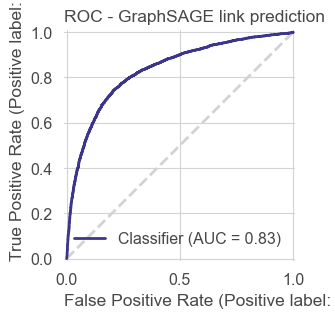

GNN AUC on the held-out CSV pairs: 0.832


,whiteboard_id,source,target,probability,prediction
0,2,robysinatra,m_rosvall,0.984,edge
1,9,ricgallotti,sees_lab,0.984,edge
2,5,yy,DanLarremore,0.981,edge
3,6,katjaQheuer,VeraPancaldi,0.861,edge
4,8,katjaQheuer,svscarpino,0.782,edge
5,4,official_SYNS,joshua_a_becker,0.725,edge
6,7,citron_daniel,richardclegg,0.676,edge
7,3,GiulioRossetti,WeiyuZ,0.518,edge
8,10,phdskat,wtgrantfdn,0.425,no edge
9,1,PolarBearby,DrBreaky,0.073,no edge


In [41]:
df_test_gnn = df_test[["node_u", "node_v", "source", "target", "label"]].copy()

# Evaluating the held-uot data
model.eval()
with torch.no_grad():
    h = model(data.x, data.edge_index)
    logits = edge_scores(h, test_edge)
df_test_gnn["pred_prob"] = torch.sigmoid(logits).numpy()
df_test_gnn["pred"] = (df_test_gnn["pred_prob"] >= 0.5).astype(int)

RocCurveDisplay.from_predictions(df_test_gnn["label"], df_test_gnn["pred_prob"])
plt.plot([0, 1], [0, 1], "--", color="lightgray", zorder=0)
plt.title("ROC - GraphSAGE link prediction")
plt.grid(True)
plt.show()

auc_gnn = roc_auc_score(df_test_gnn["label"], df_test_gnn["pred_prob"])
print(f"GNN AUC on the held-out CSV pairs: {auc_gnn:.3f}")
auc_log["gnn"] = auc_gnn
test_prediction_log["gnn"] = df_test_gnn.copy()

show_whiteboard_predictions("gnn")


### Inspect confident false positives

A high-scoring `label = 0` pair is not necessarily a silly prediction. The negative examples are sampled non-edges; some can still look structurally plausible. Try filtering the table by a node name you recognise (PiratePeel).

For a different method, use `test_prediction_log["jaccard"]` (replacing "jaccard") instead of `df_test_gnn`.



In [43]:
# For 
false_pos_gnn = (
    df_test_gnn.query("label == 0")
    .sort_values("pred_prob", ascending=False)
    .head(10)
)
display(false_pos_gnn[["source", "target", "label", "pred_prob", "pred"]])


,source,target,label,pred_prob,pred
6542,ipoga,LinZhang1117,0,1.000000,1
8570,timslarock,NUMarSci,0,0.999995,1
6585,BrainLifeio,aina_puce,0,0.999979,1
11073,netsci2020,CompSysSoc,0,0.999968,1
8062,matteo_brainnet,ar0mcintosh,0,0.999951,1
9609,kiran_tomlinson,ashton1anderson,0,0.999775,1
8228,mattbrehmer,visualisingdata,0,0.999775,1
9703,jacrickets,SamirSuweis,0,0.999658,1
10552,nwlandry,syedarehaq,0,0.999615,1
6914,mrfrank5790,ronaldomenezes,0,0.999503,1


---
## Part 5: Compare methods and top predictions

Each method saved its held-out predictions in `test_prediction_log`. Use this final section to compare AUCs, reveal the 10 whiteboard labels, and inspect the strongest predicted missing edges.

The goal is to ask: which pairs does each method rank highly, and why?


In [44]:
auc_summary = pd.DataFrame({
    "method": list(auc_log.keys()),
    "held-out AUC": list(auc_log.values()),
}).sort_values("held-out AUC", ascending=False)

auc_summary["held-out AUC"] = auc_summary["held-out AUC"].round(3)
display(auc_summary.reset_index(drop=True))


,method,held-out AUC
0,jaccard,0.895
1,gnn,0.832
2,katz,0.825
3,node2vec,0.784
4,paths,0.761
5,svd,0.756


---
## Appendix: how the test sets were created

This is documentation, not part of the demo. It shows how the shipped `*_network_prediction.graphml` training graphs and `*_network_prediction_test.csv` files were created from the raw edge lists.

The code is wrapped in `if False:` so it does not run by default.


In [ ]:
def create_network_train_test(df, net_name="twitter"):
    """Hold out 10% of edges as a test set; save the reduced graph + test CSV.

    Mirrors the function used to generate the data shipped with the course,
    but ported to use igraph.
    """
    # Symmetrise and dedup
    df = pd.concat([df, df.rename(columns={0: 1, 1: 0})]).drop_duplicates()

    g = ig.Graph.TupleList(df.itertuples(index=False), directed=False)
    g.simplify()
    g = g.connected_components().giant()

    # Relabel nodes to 0..n-1
    names = g.vs["name"]
    d_conv = {name: i for i, name in enumerate(names)}

    # Adjacency
    A = np.array(g.get_adjacency().data)
    u, v = np.nonzero(A)
    eids = np.random.permutation(len(u))
    test_size = int(len(eids) * 0.1)

    test_pos_u,  test_pos_v  = u[eids[:test_size]], v[eids[:test_size]]
    train_pos_u, train_pos_v = u[eids[test_size:]], v[eids[test_size:]]

    # Negative edges
    adj_neg = A + np.eye(g.vcount()) - 1
    neg_u, neg_v = np.nonzero(adj_neg)
    neg_eids = np.random.choice(len(neg_u), len(u))
    test_neg_u, test_neg_v = neg_u[neg_eids[:test_size]], neg_v[neg_eids[:test_size]]

    pos = pd.DataFrame(np.array([test_pos_u, test_pos_v]).T)
    pos["label"] = 1
    neg = pd.DataFrame(np.array([test_neg_u, test_neg_v]).T)
    neg["label"] = 0
    df_test = pd.concat([pos, neg])
    df_test.to_csv(f"{path_data}{net_name}_network_prediction_test.csv", sep="\t")

    # Remove held-out positives from g
    held = list(zip(test_pos_u, test_pos_v))
    eid_to_drop = g.get_eids(held, error=False)
    eid_to_drop = [e for e in eid_to_drop if e >= 0]
    g.delete_edges(eid_to_drop)

    # Persist the label attribute (original names) on the int-id vertices
    inverse = {i: n for n, i in d_conv.items()}
    g.vs["label"] = [inverse[i] for i in range(g.vcount())]
    g.vs["id"]    = [str(i)     for i in range(g.vcount())]
    g.write_graphml(f"{path_data}{net_name}_network_prediction.graphml")


if False:        # set to True to regenerate the data files
    np.random.seed(1546)
    df = pd.read_csv(f"{path_data}/ic2s2_netsci_3.tsv",
                     sep="\t", usecols=["source", "target"])
    df.columns = [0, 1]
    create_network_train_test(df, net_name="twitter")

    np.random.seed(1546)
    df = pd.read_csv(f"{path_data}/CCSB-Y2H.txt", sep="\t", header=None)
    create_network_train_test(df, net_name="ppi")
